In [89]:
from glob import glob

from _analysis import get_origins_targets, get_ssim, get_lpips, load_jsons
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde, anderson_ksamp
from scipy import stats
import re

plt.rcParams.update({
    "text.usetex": True,
    "font.size": 20,
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "legend.fontsize": 14,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})


In [2]:
usr_path = "/home/weissl"

In [3]:
e_targets, e_origins = get_origins_targets(f"{usr_path}/Projects/SMOO/defaults/hynea/runs/*/*_custom_1*", "/origin*.png", "/taget*.png")
s_tuples = [get_origins_targets(f"{path}/*", "/origin*.png", "/taget*.png") for path in glob(f"{usr_path}/Projects/SMOO/defaults/hynea/runs/hynea_custom_seed*")]

e_data = load_jsons(glob(f"{usr_path}/Projects/SMOO/defaults/hynea/runs/*/*_custom_1*/*.json"))
s_datas = [load_jsons(glob(f"{path}/*/*.json")) for path in glob(f"{usr_path}/Projects/SMOO/defaults/hynea/runs/hynea_custom_seed*")]

In [4]:
e_ssim = get_ssim(e_origins, e_targets)
s_ssims = [get_ssim(*s) for s in s_tuples]

e_lpips = get_lpips(e_origins, e_targets)
s_lpipss = [get_lpips(*s) for s in s_tuples]

e_runtime = e_data["runtime"]
s_runtimes = [s["runtime"] for s in s_datas]

In [104]:
print("Anderson K-Sample p-value, SSIM: ", anderson_ksamp([e_ssim] + s_ssims, method=stats.PermutationMethod(n_resamples=100, random_state=np.random.default_rng())).pvalue)
print("Anderson K-Sample p-value, LPIPS: ", anderson_ksamp([e_lpips] + s_lpipss, method=stats.PermutationMethod(n_resamples=100, random_state=np.random.default_rng())).pvalue)
print("Anderson K-Sample p-value, Runtime: ", anderson_ksamp([e_runtime] + s_runtimes, method=stats.PermutationMethod(n_resamples=100, random_state=np.random.default_rng())).pvalue)

Anderson K-Sample p-value, SSIM:  0.8514851485148515
Anderson K-Sample p-value, LPIPS:  0.801980198019802
Anderson K-Sample p-value, Runtime:  0.8118811881188119


/home/weissl/miniconda3/envs/hynea/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [116]:
def bootstrap_mean_ci(x, n_boot=10000, ci=99, random_state=0):
    rng = np.random.default_rng(random_state)
    x = np.asarray(x)

    means = [
        rng.choice(x, size=len(x), replace=True).mean()
        for _ in range(n_boot)
    ]

    alpha = (100 - ci) / 2
    return x.mean(), np.percentile(means, [alpha, 100 - alpha])

def plot_seed_sensitivity(
    baseline_data,
    seed_data,
    seed_labels,
    metric_name,
    n_boot=10000,
    ci=99,
    random_state=0,
):
    baseline_data = np.asarray(baseline_data)
    seed_data = [np.asarray(d) for d in seed_data]

    baseline_mean, ci_bounds = bootstrap_mean_ci(
        baseline_data, n_boot, ci, random_state
    )
    seed_means = [d.mean() for d in seed_data]

    fig, ax = plt.subplots(figsize=(7, 5))
    from matplotlib.ticker import ScalarFormatter

    class IntegerScalarFormatter(ScalarFormatter):
        def _set_format(self):
            self.format = "%d"

    formatter = IntegerScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))

    ax.yaxis.set_major_formatter(formatter)


    x_min = min([baseline_data.min()] + [d.min() for d in seed_data])
    x_max = max([baseline_data.max()] + [d.max() for d in seed_data])
    x = np.linspace(x_min, x_max, 500)

    ax.axvspan(*ci_bounds, color="0.88", zorder=0)

    for d, label, ls in zip(seed_data, seed_labels, ["-", "--", "-.", ":"] * 10):
        ax.plot(
            x,
            gaussian_kde(d)(x),
            color="tab:blue",
            linestyle=ls,
            linewidth=1.5,
            alpha=0.65,
            label=label,
        )

    ax.plot(
        x,
        gaussian_kde(baseline_data)(x),
        color="tab:red",
        linewidth=3,
        label=r"Default",
    )

    ax.axvline(baseline_mean, color="black", linestyle="--", linewidth=1.5)

    marker_y = 0.04 * ax.get_ylim()[1]

    ax.scatter(seed_means, [marker_y] * len(seed_means), color="tab:blue",
               edgecolor="black", s=120, zorder=12)
    ax.scatter([baseline_mean], [marker_y], color="black", marker="D",
               s=110, zorder=13)

    pad = 0.005 * (x_max - x_min)
    ax.set_xlim(x_min - pad, x_max + pad)
    ax.set_xlabel(rf"{metric_name}")
    ax.set_ylabel(r"Density")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=True, loc="best")

    plt.savefig(f"_figures/seed_sens_{metric_name}.pdf", dpi=200, bbox_inches="tight")


def extract_seed(path):
    m = re.search(r"seed[_-]?(\d+)", path)
    return int(m.group(1)) if m else np.inf

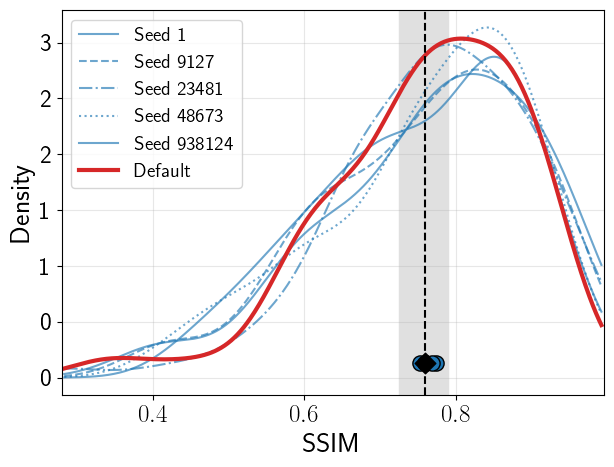

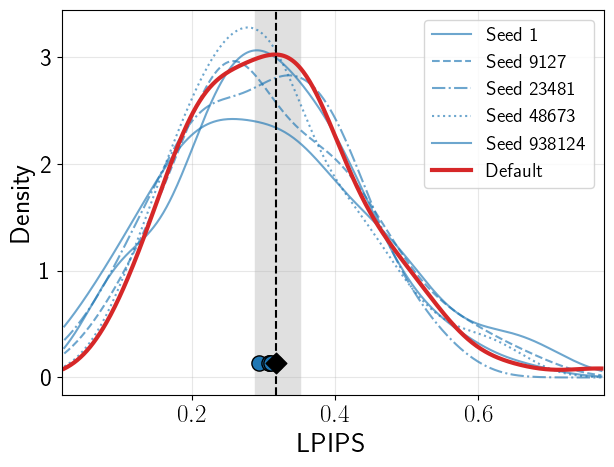

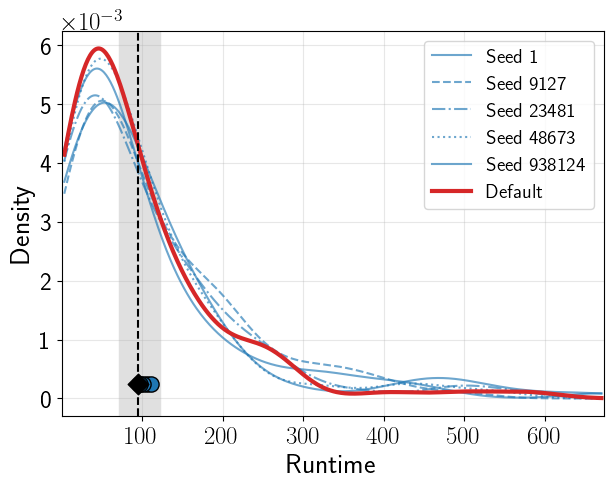

In [117]:
seed_paths = glob(f"{usr_path}/Projects/SMOO/defaults/hynea/runs/hynea_custom_seed*")
seed_order = np.argsort([extract_seed(p) for p in seed_paths])

seed_paths = [seed_paths[i] for i in seed_order]
seed_labels = [rf"Seed {extract_seed(p)}" for p in seed_paths]

s_ssims_sorted = [s_ssims[i] for i in seed_order]
s_lpipss_sorted = [s_lpipss[i] for i in seed_order]
s_runtimes_sorted = [s_runtimes[i] for i in seed_order]

plot_seed_sensitivity(e_ssim, s_ssims_sorted, seed_labels, r"SSIM")
plot_seed_sensitivity(e_lpips, s_lpipss_sorted, seed_labels, r"LPIPS")
plot_seed_sensitivity(e_runtime, s_runtimes_sorted, seed_labels, r"Runtime")